#Progetto del corso - Introduzione alla Data Science e al Pensiero Computazionale - a.a. 2025/2026

#Membri del Gruppo n° XY:

*   **Filippo Vignoli:** matricola 0001217390, email filippo.vignoli@studio.unibo.it
*   **Fabio Sola:** matricola 0001231148, email fabio.sola2@studio.unibo.it

#Analisi del churn dei clienti di una società telco

* **Dataset:** Customer_Churn.csv

#Obiettivo del Progetto
L'obiettivo di questo progetto è analizzare i fattori che determinano **l'abbandono dei clienti** (cd *customer churn*) per una compagnia di telecomunicazioni e sviluppare modelli di Machine Learning in grado di **predire preventivamente quali utenti sono a rischio di cancellazione del servizio**.

# Preparazione dell'ambiente

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Fetch a single <1MB file using the raw GitHub URL.
!curl --remote-name \
     -H 'Accept: application/vnd.github.v3.raw' \
     --location https://raw.githubusercontent.com/SolFa688/Progetto_IntroDSePC_gruppo_n16/refs/heads/main/data/Customer_Churn.csv

df = pd.read_csv("Customer_Churn.csv")

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  954k  100  954k    0     0  3406k      0 --:--:-- --:--:-- --:--:-- 3397k


# Parte 1 - Descrizione e comprensione del dataset

Objective: Predict whether a customer will churn (i.e., discontinue the service).

The data set includes information about:
* Customers who left within the last month:
   - the column is called Churn
* Services that each customer has signed up for
  - phone,
  - multiple lines,
  - internet,
  - online security,
  - online backup,
  - device protection,
  - tech support,
  - and streaming TV and
  -  movies
* Customer account information
  - how long they’ve been a customer,
  - contract,
  - payment method,
  - paperless billing,
  - monthly charges, and
  - total charges
* Demographic info about customers
  -  gender,
  - age range,
  - and if they have
    - partners and
    - dependents

***********************************

***Column name and description***

***********************************

`customerID`: Customer ID

`gender`: Whether the customer is a male or a female

`SeniorCitizen`: Whether the customer is a senior citizen or not (1, 0)

`Partner`: Whether the customer has a partner or not (Yes, No)

`Dependents`: Whether the customer has dependents or not (Yes, No)

`tenure`: Number of months the customer has stayed with the company

`PhoneService`: Whether the customer has a phone service or not (Yes, No)

`MultipleLines`: Whether the customer has multiple lines or not (Yes, No, No phone service)

`InternetService`: Customer’s internet service provider (DSL, Fiber optic, No)

`OnlineSecurity`: Whether the customer has online security or not (Yes, No, No internet service)

`OnlineBackup`: Whether the customer has online backup or not (Yes, No, No internet service)

`DeviceProtection`: Whether the customer has device protection or not (Yes, No, No internet service)

`TechSupport`: Whether the customer has tech support or not (Yes, No, No internet service)

`StreamingTV`: Whether the customer has streaming TV or not (Yes, No, No internet service)

`StreamingMovies`: Whether the customer has streaming movies or not (Yes, No, No internet service)

`Contract`: The contract term of the customer (Month-to-month, One year, Two year)

`PaperlessBilling`: Whether the customer has paperless billing or not (Yes, No)

`PaymentMethod`: The customer’s payment method (Electronic check, Mailed check, Bank transfer (automatic), Credit card (automatic))

`MonthlyCharges`: The amount charged to the customer monthly

`TotalCharges`: The total amount charged to the customer

`Churn`: Whether the customer churned or not (Yes or No)

Questo dataset raccoglie i dati dei clienti di un'azienda di telecomunicazioni ed è strutturato per analizzare e prevedere il fenomeno del *churn*, che è la nostra variabile target e indica se il cliente ha abbandonato la compagnia (*Yes*) o è ancora attivo (*No*).

Il dataset è costituito da:

1. **Informazioni demografiche**
   * **gender**: sesso del cliente.
   * **SeniorCitizen**: indicatore di appartenenza alla fascia anziani (0 o 1).
   * **Partner & Dependents**: presenza di un partner o di familiari a carico.

2. **Servizi attivati**
   * **Connettività**: tipologia di linea telefonica (PhoneService, MultipleLines) e tipo di connessione internet (InternetService: DSL, Fibra ottica o Nessuna).
   * **Servizi di sicurezza e supporto**: abbonamenti a sicurezza online (OnlineSecurity), backup (OnlineBackup), protezione dispositivi (DeviceProtection) e assistenza tecnica (TechSupport).
   * **Intrattenimento**: servizi di streaming TV (StreamingTV) e film (StreamingMovies).

3. **Dettagli contrattuali e finanziari**
   * **tenure**: fedeltà del cliente espressa in mesi di permanenza (da 0 a 72 mesi).
   * **Contract**: durata del contratto (rinnovo mensile, annuale o biennale).
   * **Fatturazione e Pagamenti**: opzione di fatturazione digitale (PaperlessBilling), metodo di pagamento utilizzato (PaymentMethod), costo mensile (MonthlyCharges) e spesa totale accumulata (TotalCharges).

## Domanda 1.1: quali sono le dimensioni del dataset?

In [29]:
print ("Il dataset è composto da", df.shape[0], "righe e",df.shape[1], "colonne")
print ("Per un totale di", df.size, "valori presenti")
df

Il dataset è composto da 7043 righe e 21 colonne
Per un totale di 147903 valori presenti


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [52]:
# Rimozione della colonna customerID
df.drop(columns=['customerID'], inplace=True)
print("Colonna 'customerID' rimossa correttamente.")
display(df.head())

Colonna 'customerID' rimossa correttamente.


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [50]:
df.drop("customerID", axis=1).inplace=False

In [44]:
for col in df.columns:
    print(f"--- Colonna: {col} ---")
    print(f"Size: {df[col].size}")
    print(df[col].value_counts())
    print("\n")

--- Colonna: customerID ---
Size: 7043
customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
8775-CEBBJ    1
2823-LKABH    1
             ..
6713-OKOMC    1
1452-KIOVK    1
9305-CDSKC    1
9237-HQITU    1
7795-CFOCW    1
Name: count, Length: 7043, dtype: int64


--- Colonna: gender ---
Size: 7043
gender
Male      3555
Female    3488
Name: count, dtype: int64


--- Colonna: SeniorCitizen ---
Size: 7043
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64


--- Colonna: Partner ---
Size: 7043
Partner
No     3641
Yes    3402
Name: count, dtype: int64


--- Colonna: Dependents ---
Size: 7043
Dependents
No     4933
Yes    2110
Name: count, dtype: int64


--- Colonna: tenure ---
Size: 7043
tenure
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: count, Length: 73, dtype: int64


--- Colonna: PhoneService ---
Size: 7043
PhoneService
Yes    6361
No      682
Name: count, dtype: int64


--- Colonna: MultipleLines ---
S

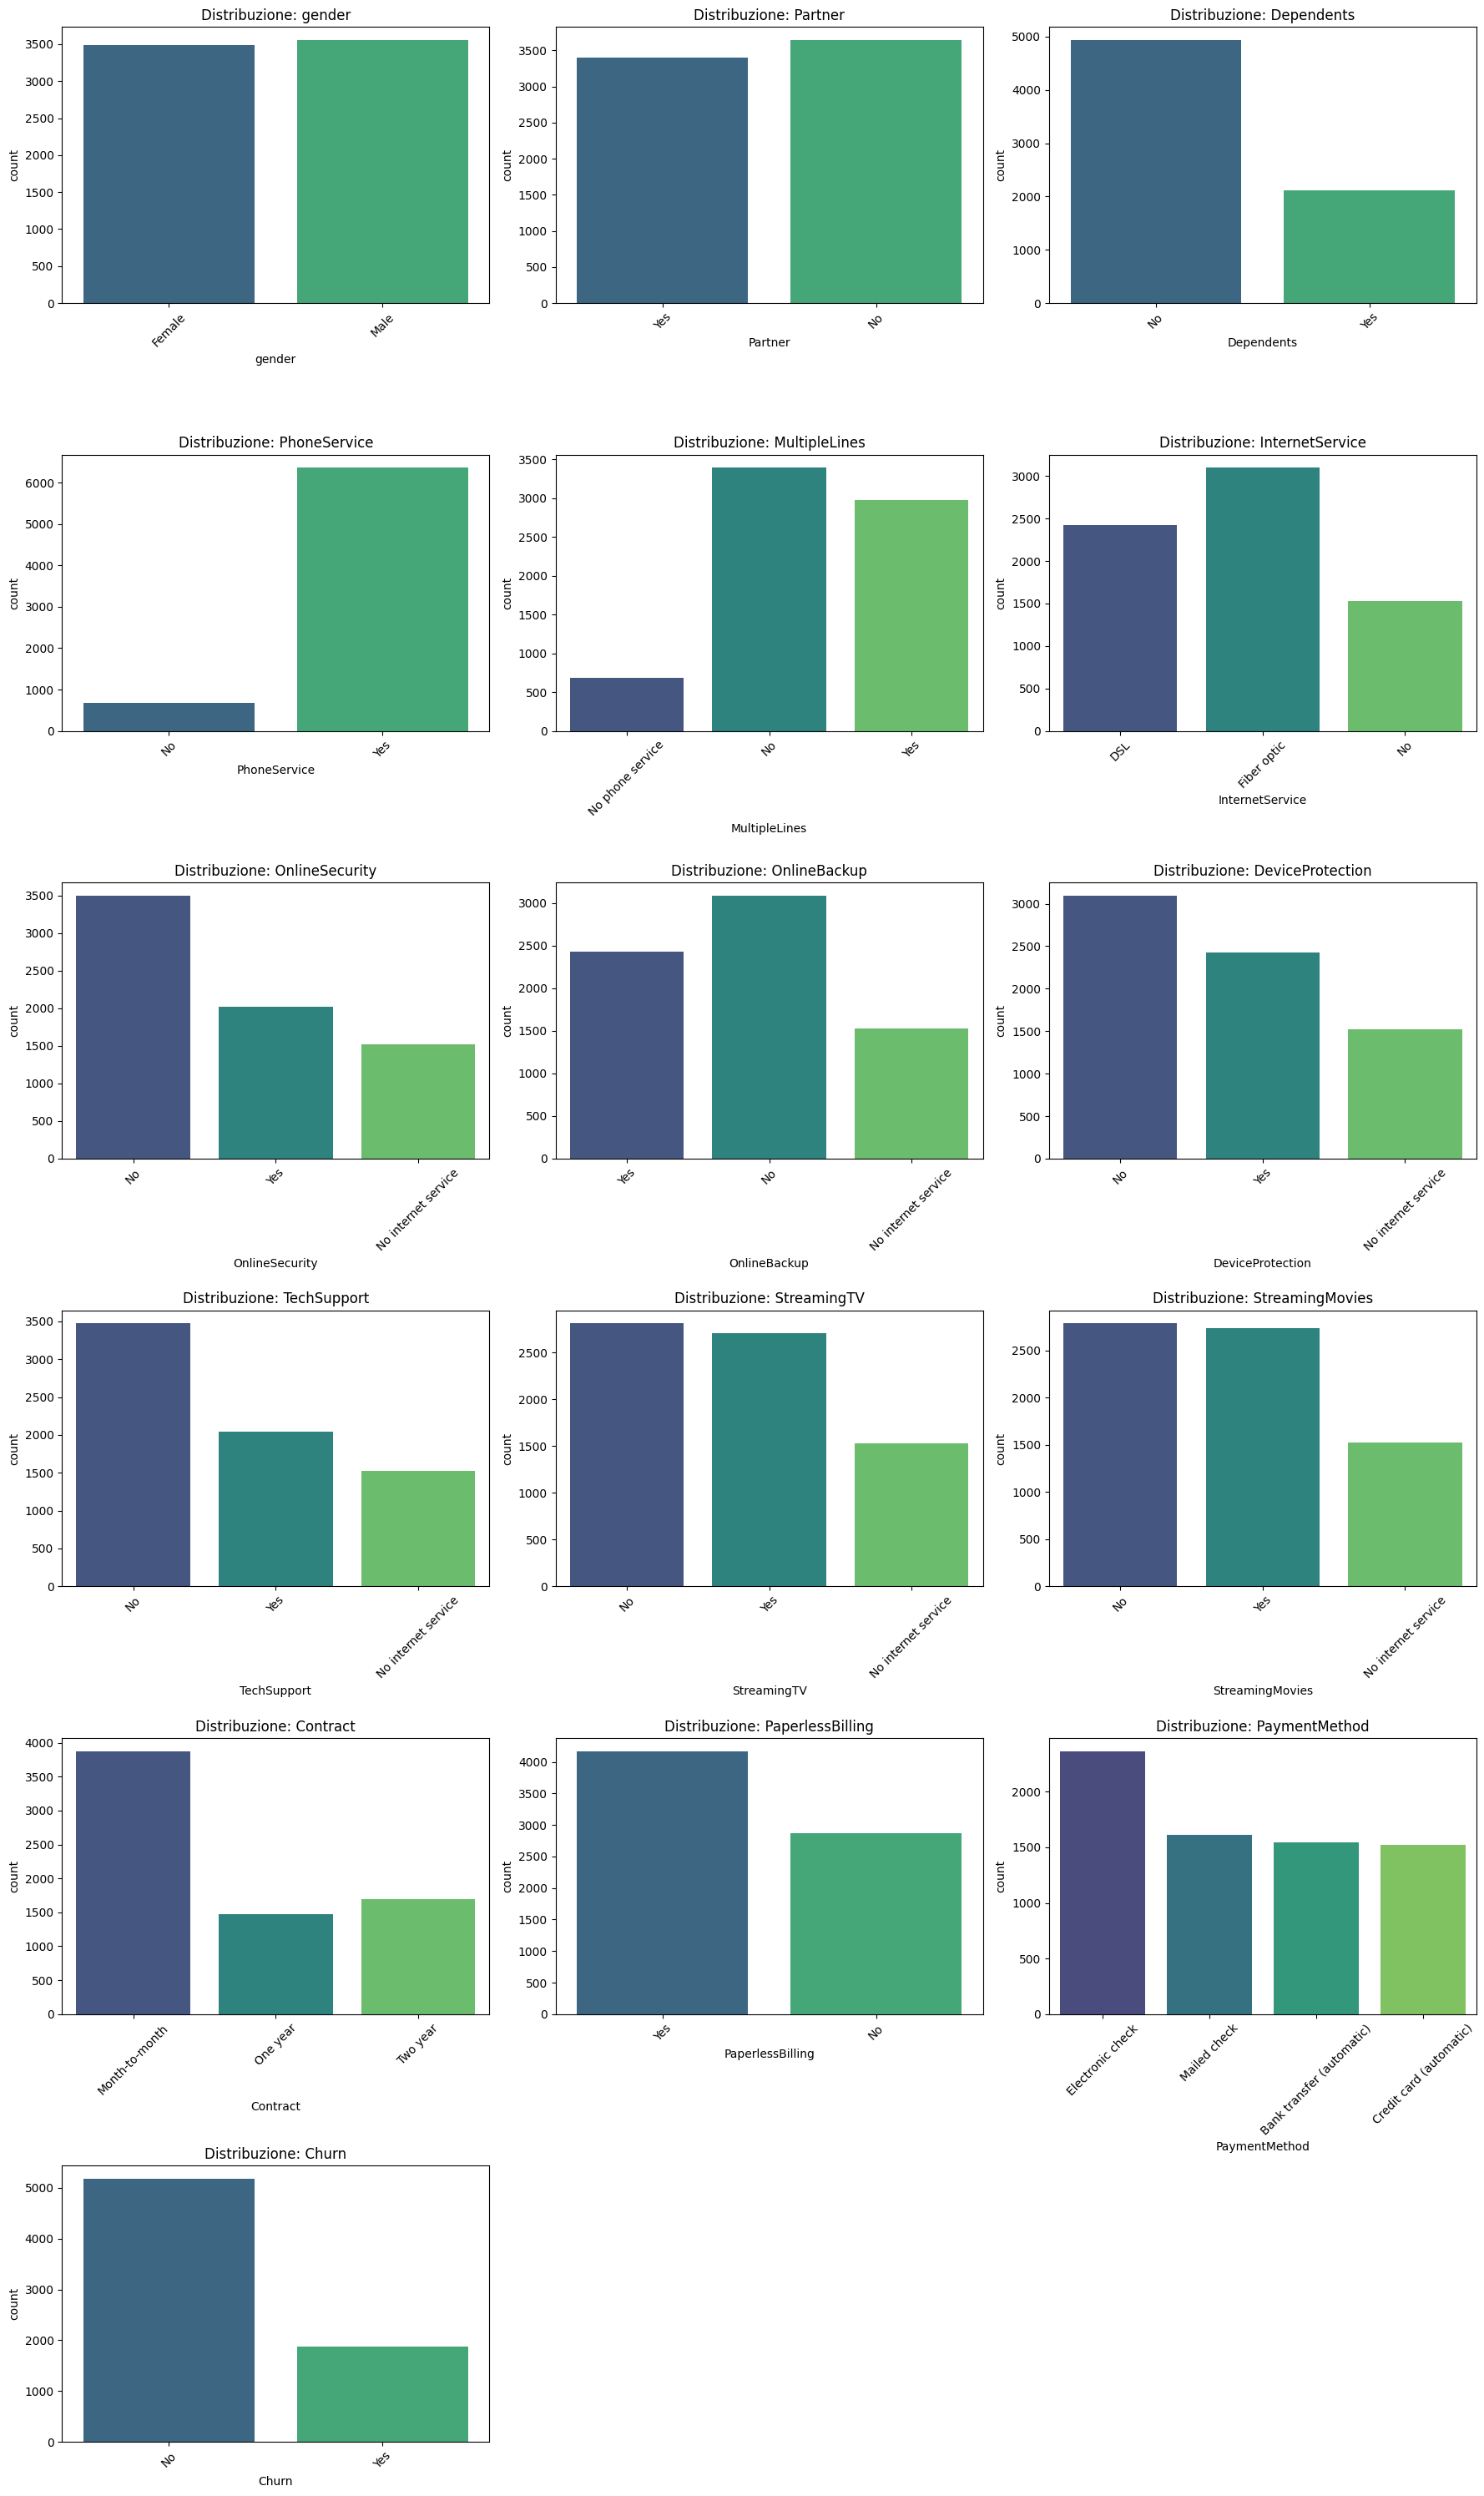

In [45]:
import math

# Filtriamo le colonne categoriche (escludendo l'ID)
cat_cols = [c for c in df.columns if df[c].dtype == 'object' and c != 'customerID']
n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', hue=col, legend=False)
    axes[i].set_title(f'Distribuzione: {col}')
    axes[i].tick_params(axis='x', rotation=45)

# Rimuoviamo gli assi vuoti se presenti
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [53]:
summary_list = []
for col in df.columns:
    counts = df[col].value_counts().to_dict()
    summary_list.append({
        "Colonna": col,
        "Size": df[col].size,
        "Valori Unici": len(counts),
        "Dettaglio Conteggi": counts
    })

df_summary = pd.DataFrame(summary_list)
display(df_summary)

,Colonna,Size,Valori Unici,Dettaglio Conteggi
0,gender,7043,2,"{'Male': 3555, 'Female': 3488}"
1,SeniorCitizen,7043,2,"{0: 5901, 1: 1142}"
2,Partner,7043,2,"{'No': 3641, 'Yes': 3402}"
3,Dependents,7043,2,"{'No': 4933, 'Yes': 2110}"
4,tenure,7043,73,"{1: 613, 72: 362, 2: 238, 3: 200, 4: 176, 71: ..."
5,PhoneService,7043,2,"{'Yes': 6361, 'No': 682}"
6,MultipleLines,7043,3,"{'No': 3390, 'Yes': 2971, 'No phone service': ..."
7,InternetService,7043,3,"{'Fiber optic': 3096, 'DSL': 2421, 'No': 1526}"
8,OnlineSecurity,7043,3,"{'No': 3498, 'Yes': 2019, 'No internet service..."
9,OnlineBackup,7043,3,"{'No': 3088, 'Yes': 2429, 'No internet service..."


In [37]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


## Domanda 1.2: quali tipi di dati sono collezionati?

Il dataset contiene:
* **3 variabili numeriche** (SeniorCitizen, tenure, MonthlyCharges);
* **18 variabili categoriche** (object).

**Si rileva un'anomalia critica:** "TotalCharges" è interpretata come object anziché numerica a causa della presenza di spazi vuoti (" ") per i nuovi clienti con tenure = 0.

A questo proposito, **convertiamo le stringhe vuote/non valide in NaN e la colonna in float e sostituiamo i NaN con 0** (coerentemente con tenure = 0 per i nuovi clienti):

In [36]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df["TotalCharges"] = df["TotalCharges"].fillna(0)

## Domanda 1.3: sono presenti valori numerici non definiti (NaN) o valori mancanti (N/A)?

A un'analisi iniziale **non risultano valori nulli espliciti**. Tuttavia, sono presenti **11 valori mancanti "impliciti" (stringhe vuote) nella colonna TotalCharges**, corrispondenti a nuovi clienti con tenure = 0. Con il passaggio precedente, tali valori sono stati convertiti in NaN ed imputati a 0 per garantire la pulizia del dataset.

##Domanda 1.4: caratteristiche descrittive dei valori numerici presenti

In [ ]:
print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe().round(2))
print("\n")

        tenure  MonthlyCharges  TotalCharges
count  7043.00         7043.00       7043.00
mean     32.37           64.76       2279.73
std      24.56           30.09       2266.79
min       0.00           18.25          0.00
25%       9.00           35.50        398.55
50%      29.00           70.35       1394.55
75%      55.00           89.85       3786.60
max      72.00          118.75       8684.80




La variabile "tenure" copre un arco da 0 a 72 mesi con una media di 32.37 mesi e una mediana di 29.
"MonthlyCharges" varia da 18.25 USD a 118.75 USD (media 64.76 USD), mostrando la coesistenza di utenti con soli servizi base e utenti con pacchetti avanzati.

## Domanda 1.5: distribuzione della variabile target "churn"

In [ ]:
print(df['Churn'].value_counts())
print("\nDistribuzione in percentuale:")
print(df['Churn'].value_counts(normalize=True).map('{:.2%}'.format))

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Distribuzione in percentuale:
Churn
No     73.46%
Yes    26.54%
Name: proportion, dtype: object


**Si riscontra uno sbilanciamento delle classi: 73.46% "No" contro 26.54% "Yes"**. Come avremo modo di constatare anche in seguito alla visualizzazione in Domanda 2.1, questo squilibrio richiederà l'uso di uno split stratificato (stratify=df.Churn) e di metriche di valutazione focalizzate su recall e F1-score anziché sulla semplice accuracy.

## Domanda 1.6: come sono distribuiti i valori?

In [ ]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.16,0.37,0.00,0.00,0.00,0.00,1.00
tenure,7043.0,32.37,24.56,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.76,30.09,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.73,2266.79,0.00,398.55,1394.55,3786.60,8684.80


L'analisi mostra che i clienti anziani (SeniorCitizen = 1) rappresentano soltanto il 16% del totale. **Le variabili continuative non mostrano asimmetrie estreme, coprendo in modo uniforme i range di riferimento**.

## Domanda 1.7: ci sono valori anomali (outlier) nelle variabili continue?

In [ ]:
continue_cols = ["MonthlyCharges", "TotalCharges", "tenure"]
righe = []

for c in continue_cols:
    # Convertiamo la colonna in numerico (forzando ad NaN eventuali stringhe vuote/non valide)
    s = pd.to_numeric(df[c], errors="coerce").dropna()

    if len(s) == 0:
        continue
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((s < lo) | (s > hi)).sum()
    righe.append(
        {
            "Variabile": c,
            "Q1": round(q1, 2),
            "Q3": round(q3, 2),
            "Soglia bassa": round(lo, 1),
            "Soglia alta": round(hi, 1),
            "N. outlier": int(n_out),
            "% outlier": round(n_out / len(s) * 100, 2),
            "Max": round(s.max(), 2),
        }
    )

df_outliers = pd.DataFrame(righe)
df_outliers

,Variabile,Q1,Q3,Soglia bassa,Soglia alta,N. outlier,% outlier,Max
0,MonthlyCharges,35.50,89.85,-46.0,171.4,0,0.0,118.75
1,TotalCharges,398.55,3786.60,-4683.5,8868.7,0,0.0,8684.80
2,tenure,9.00,55.00,-60.0,124.0,0,0.0,72.00


L'analisi effettuata con il metodo del range iterquartile (IQR) indica **0 outlier per "MonthlyCharges", "TotalCharges" e "tenure"**. Questo ci porta a pensare che valori siano tutti realistici: la permanenza massima è di 72 mesi (cioè 6 anni) e la spesa mensile più alta è di 118,75 USD. Quindi, **in queste 3 variabili non riscontriamo alcun valore anomalo da eliminare o da correggere**.

## Domanda 1.8: quali sono le caratteristiche del *cliente tipo* che abbandona il servizio?

In [ ]:
df.drop ("Churn", axis=1).mode().iloc[0]

,0
customerID,0002-ORFBO
gender,Male
SeniorCitizen,0.0
Partner,No
Dependents,No
tenure,1.0
PhoneService,Yes
MultipleLines,No
InternetService,Fiber optic
OnlineSecurity,No


**L'identikit dell'utente a maggior rischio di abbandono è:**

* uomo;
* non anziano;
* single e senza familiari a carico;
* con 1 mese di permanenza;
* con linea in fibra ottica;
* senza alcun servizio di protezione/supporto;
* con contratto mensile;
* che adopera fatturazione paperless e modalità di pagamento via bonifico elettronico.

## Domanda 1.9: quali variabili sono più correlate con l'abbandono (churn)?

In [ ]:
# conversione di TotalCharges in variabile numerica
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# copia del dataframe ed eliminazione dell'ID per evitare problemi con eventuali valori NaN
num_cols = df.drop(columns=["customerID"], errors="ignore").copy()

# mappatura e codifica delle variabili categoriche
num_cols["Churn"] = num_cols["Churn"].map({"No": 0, "Yes": 1})
num_cols["gender"] = num_cols["gender"].map({"Female": 0, "Male": 1})
num_cols["Partner"] = num_cols["Partner"].map({"No": 0, "Yes": 1})
num_cols["Dependents"] = num_cols["Dependents"].map({"No": 0, "Yes": 1})
num_cols["PhoneService"] = num_cols["PhoneService"].map({"No": 0, "Yes": 1})
num_cols["PaperlessBilling"] = num_cols["PaperlessBilling"].map({"No": 0, "Yes": 1})

num_cols["Contract"] = num_cols["Contract"].map(
    {"Month-to-month": 0, "One year": 1, "Two year": 2})

categorical_cols = num_cols.select_dtypes(include=["object"]).columns
for col in categorical_cols:
    num_cols[col] = num_cols[col].astype("category").cat.codes

corr_churn = num_cols.corr(method="spearman")["Churn"].drop("Churn")

index_ordinato = corr_churn.abs().sort_values(ascending=False).index
corr_churn_ordinata = corr_churn.reindex(index_ordinato)

corr_churn.to_frame("Correlazione di Spearman con Churn").round(3)

,Correlazione di Spearman con Churn
gender,-0.009
SeniorCitizen,0.151
Partner,-0.150
Dependents,-0.164
tenure,-0.367
PhoneService,0.012
MultipleLines,0.038
InternetService,-0.029
OnlineSecurity,-0.304
OnlineBackup,-0.203


**1. Correlazione negativa (fattori di fidelizzazione):**
* Tipo di contratto (Contract: -0.406): è la variabile con la correlazione negativa più forte. Passare da contratti mensili a contratti annuali o biennali riduce drastica e direttamente il rischio di churn.
* Permanenza (tenure: -0.367): più un cliente è fidelizzato alla compagnia, meno è probabile che decida di andarsene.
* Servizi di supporto (OnlineSecurity: -0.304, TechSupport: -0.297): l'adozione di servizi aggiuntivi di sicurezza o assistenza tecnica aumenta l'ingaggio dell'utente con l'operatore, riducendo l'abbandono.
* Spesa totale (TotalCharges: -0.232): i clienti con spesa cumulata alta sono anche quelli con un'elevata permanenza (tenure) e mostrano una minore propensione al churn.
* Relazioni personali (Dependents: -0.164, Partner: -0.150): avere familiari a carico o un partner riduce lievemente la mobilità verso altri operatori.

**2. Correlazione positiva (fattori di rischio):**
* Fatturazione digitale (PaperlessBilling: +0.192): chi riceve bollette digitali tende ad abbandonare più frequentemente, probabilmente per una maggiore inclinazione alla gestione online e al cambio rapido di gestore.
* Costo mensile (MonthlyCharges: +0.185): tariffe mensili più elevate aumentano la spinta a cercare offerte concorrenziali più economiche.
* Età avanzata (SeniorCitizen: +0.151): gli utenti più anziani mostrano un tasso di churn leggermente più alto rispetto ai più giovani.
* Metodo di pagamento (PaymentMethod: +0.102): l'uso di metodi manuali/online (come l'Electronic check) mostra una correlazione positiva con il churn rispetto ai metodi automatici.

**3. Correlazione Assente o Trascurabile:**
* Sesso (gender: -0.009): non esiste alcuna differenza tra uomini e donne rispetto al churn.
* Servizio telefonico (PhoneService: +0.012): la presenza della sola linea telefonica base non incide sull'abbandono.
* Intrattenimento (StreamingTV: -0.038, StreamingMovies: -0.039): i servizi di streaming da soli non spostano l'ago della bilancia della fedeltà alla compagnia.

***NOTA:** Rimandiamo alla Domanda 2.5 per la relativa visualizzazione grafica.*

##Domanda 1.10: qual è la media di spesa mensile per tipo di contratto?

In [ ]:
print(df.groupby('Contract')['MonthlyCharges'].mean())

Contract
Month-to-month    66.398490
One year          65.048608
Two year          60.770413
Name: MonthlyCharges, dtype: float64


I clienti con contratto mese per mese pagano in media di più (66.40 USD) rispetto a chi ha contratti annuali (65.05 USD) o biennali (60.77 USD).

**L'assenza di vincoli abbinata a tariffe mensili più alte potrebbe incentivare il cambio di gestore.**

# Parte 2 - Analisi esplorativa e visualizzazione

In questa fase andremo ad analizzare ulteriormente i dati del dataset di addestramento attraverso l'utilizzo di **grafici esplicativi**.

##Domanda 2.1: qual è la proporzione della variabile target "churn" nel dataset?

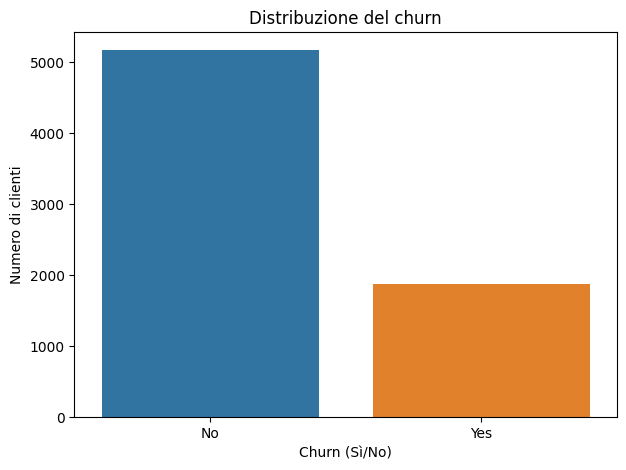

In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Churn", hue="Churn")
plt.title("Distribuzione del churn")
plt.xlabel("Churn (Sì/No)")
plt.ylabel("Numero di clienti")
plt.show()

Il grafico a barre ribadisce visivamente **la sproporzione tra utenti mantenuti e persi** dalla compagnia.

**Questo ha un impatto metodologico cruciale:** addestrare un algoritmo di Machine Learning su un dataset così conformato potrebbe portare il modello a predire quasi sempre la classe maggioritaria (*No churn*), cadendo in una dinamica di *bias* predittivo.

Come già anticipato nella Domanda 1.5, **sarà quindi fondamentale ricorrere a uno split stratificato nella Parte 3 e valutare i modelli su metriche ad hoc** (come Recall e F1-Score per la classe *Yes*), anziché basarsi unicamente sull'Accuracy generale.

##Domanda 2.2: in che modo la permanenza influisce sul churn?

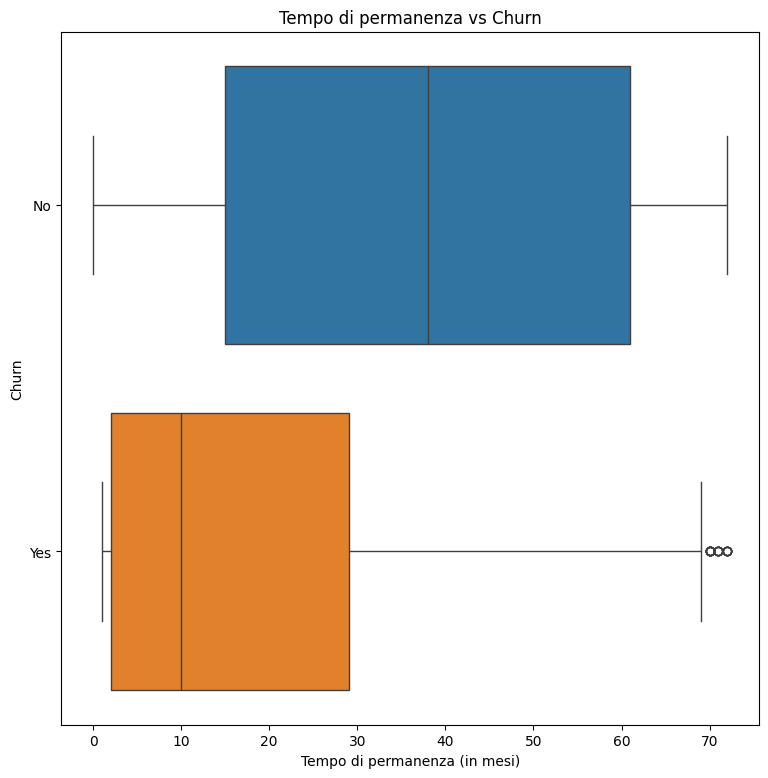

In [ ]:
plt.figure(figsize=(9, 9))
sns.boxplot(data=df, x="tenure", y="Churn", hue="Churn")
plt.title("Tempo di permanenza vs Churn")
plt.xlabel("Tempo di permanenza (in mesi)")
plt.ylabel("Churn")
plt.show()

Per i clienti che abbandonano, la linea della mediana si posiziona attorno ai 10 mesi di permanenza, con un 50\% centrale dei dati (IQR) compreso approssimativamente tra i 2 e i 29 mesi.

La mediana dei clienti che restano, invece, si attesta intorno ai 37 mesi. Il limite superiore dell'intervallo è di circa 72 mesi.

Si notano anche tre  *outlier* (clienti storici che hanno lasciato solo dopo molto tempo).

**Il churn è quindi un fenomeno concentrato prevalentemente nei primi mesi di vita del contratto.** Più un utente supera la soglia dei primi mesi di servizio, più diventa propenso a rimanere fedele all'azienda nel lungo periodo.

##Domanda 2.3: il tipo di contratto e la spesa influenzano la scelta di abbandonare la compagnia?

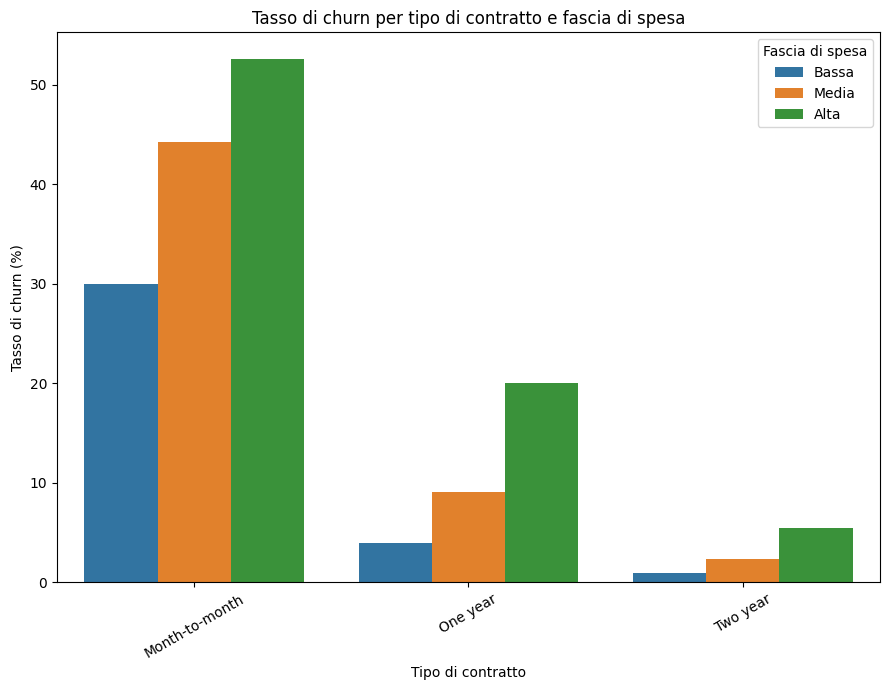

In [ ]:
df["fascia_spesa"] = pd.qcut(df["MonthlyCharges"], q=3, labels=["Bassa", "Media", "Alta"])

df["Churn_count"] = df["Churn"].map({"Yes": 1, "No": 0})
churn_rates = df.groupby(["Contract", "fascia_spesa"], observed=False)["Churn_count"].mean().reset_index()
churn_rates['Churn_rate'] = churn_rates['Churn_count'] * 100

plt.figure(figsize=(9, 7))
sns.barplot(data=churn_rates, x = "Contract" , y = "Churn_rate" , hue = "fascia_spesa")

plt.title("Tasso di churn per tipo di contratto e fascia di spesa")
plt.xlabel("Tipo di contratto")
plt.xticks(rotation=30)
plt.ylabel("Tasso di churn (%)")
plt.legend(title="Fascia di spesa")
plt.tight_layout()
plt.show()

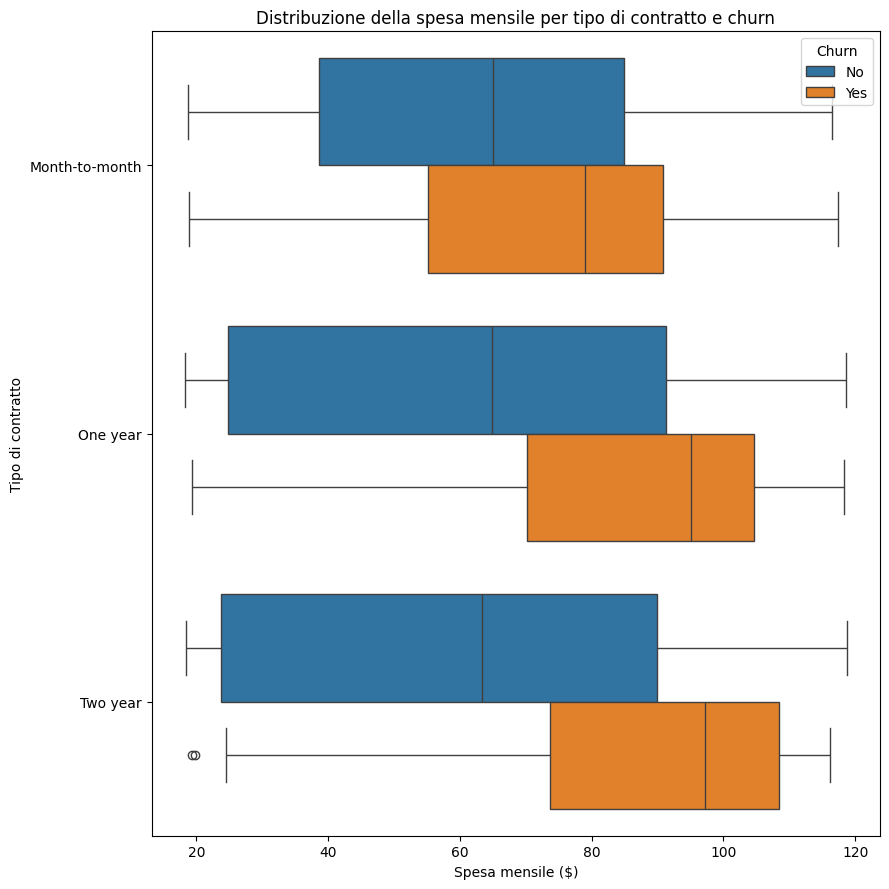

In [ ]:
plt.figure(figsize=(9, 9))

sns.boxplot(
    data=df,
    x="MonthlyCharges",  #variabile numerica su X
    y="Contract",        #variabile categorica su Y
    hue="Churn"
)

plt.title("Distribuzione della spesa mensile per tipo di contratto e churn")
plt.xlabel("Spesa mensile ($)")
plt.ylabel("Tipo di contratto")
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

I grafici indicano come nei contratti mensili con spesa "alta" il churn supera il 50%. Nei contratti ad 1 e 2 anni il tasso scende rispettivamente sotto il 20% e il 6%, dimostrando che il vincolo contrattuale mitiga l'impatto negativo dei costi elevati.

**Quindi, i clienti più inclini ad abbandonare sono quelli che pagano tariffe mensili elevate senza vincoli contrattuali a lungo termine**.

##Domanda 2.4: qual è la relazione tra il metodo di pagamento e il tasso di churn?

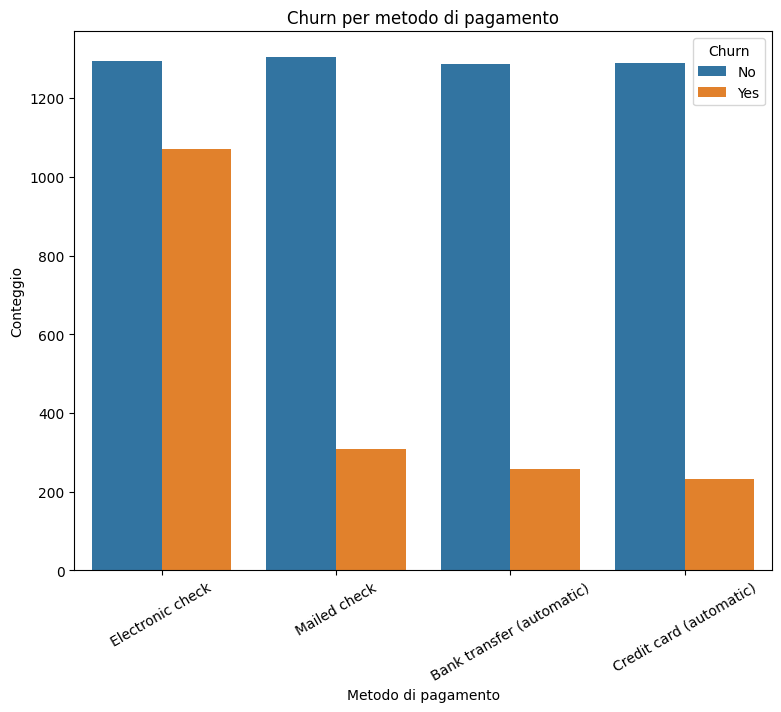

In [ ]:
plt.figure(figsize=(9, 7))
sns.countplot(data=df, x="PaymentMethod", hue="Churn")
plt.title("Churn per metodo di pagamento")
plt.xlabel("Metodo di pagamento")
plt.ylabel("Conteggio")
plt.xticks(rotation=30)
plt.show()

**Il metodo "Electronic check" presenta un tasso di abbandono sproporzionatamente alto rispetto agli altri.**

I metodi automatici (addebito bancario e carta di credito) mostrano tassi di retention decisamente superiori, suggerendo una correlazione tra pagamento automatizzato e stabilità del cliente.

Probabilmente, questi ultimi riducono la frequenza di valutazione consapevole della fattura da parte del cliente, aumentando la fidelizzazione.

**Promuovere transizioni verso pagamenti automatizzati potrebbe rivelarsi un'ottima strategia di prevenzione del churn.**

##Domanda 2.5: qual è la relazione tra spesa mensile e pesa totale e come varia la probabilità di churn lungo questa distribuzione?

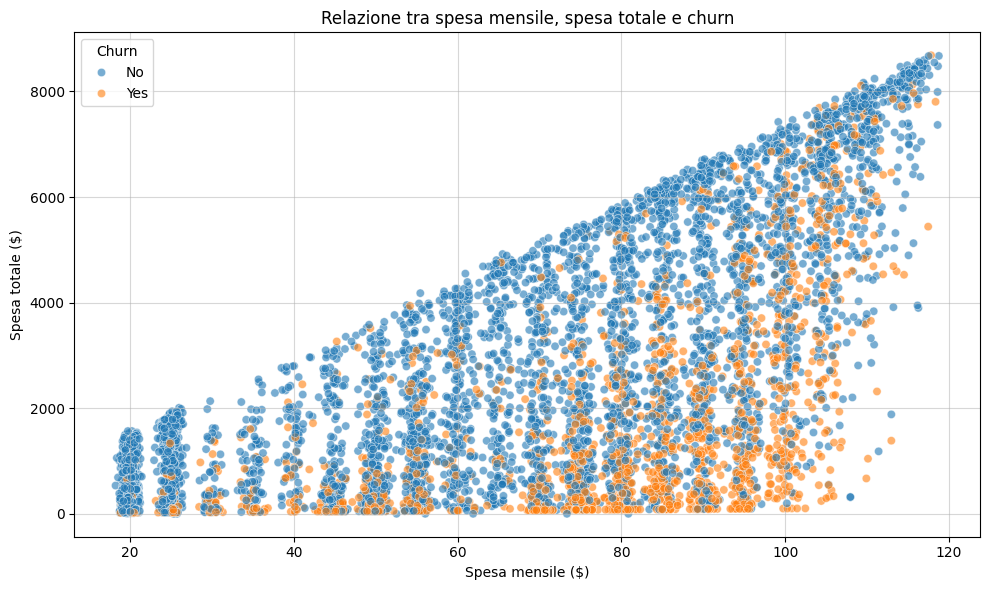

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="MonthlyCharges",
    y="TotalCharges",
    hue="Churn",
    alpha=0.6,
)

plt.title("Relazione tra spesa mensile, spesa totale e churn")
plt.xlabel("Spesa mensile ($)")
plt.ylabel("Spesa totale ($)")
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

Dallo scatterplot emerge con chiarezza la dinamica del churn in relazione alla spesa.

Si nota una forte concentrazione di abbandoni nella fascia con spesa mensile elevata (> 70 USD) e spesa totale contenuta (< 2000 USD).

Questo comportamento individua **un segmento di utenti "nuovi" o recenti che, a fronte di un canone mensile alto, tendono ad abbandonare precocemente il servizio.**

Al contrario, **la fascia a basso costo mensile (20-40 USD) presenta tassi di abbandono trascurabili**.

Infine, per valori elevati di spesa totale accumulata, la prevalenza di clienti attivi (punti blu) conferma che **l'anzianità contrattuale e il valore complessivo generato agiscono come fattori protettivi contro il churn**. Potrebbe trattarsi di una fascia di clienti più "abitudinaria" e meno avvezza al controllo di tariffe alternative e più convenienti (es. attraverso comparatori online).

##Domanda 2.6: quali sono le variabili maggiormente correlate con l'abbandono del cliente?

Ricollegandoci a ciò che è già emerso dalla Domanda 1.9, visualizziamo i risultati tramite una heatmap monocolonna:

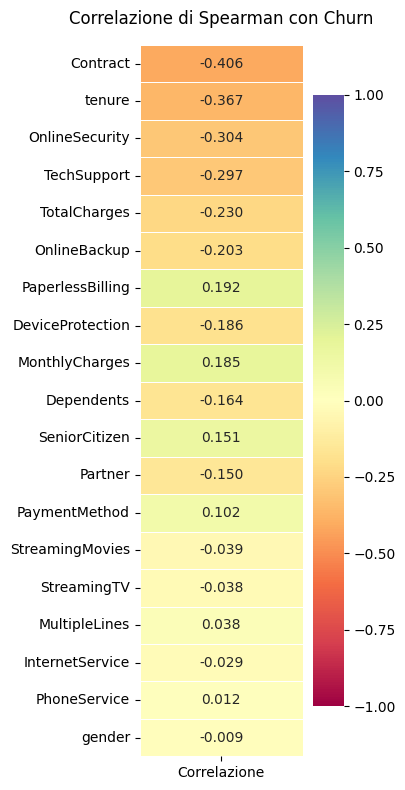

In [ ]:
#prepariamo i dati ordinandoli per valore assoluto di correlazione
index_ordinato = corr_churn.abs().sort_values(ascending=False).index
corr_churn_df = corr_churn.reindex(index_ordinato).to_frame(
    name="Correlazione"
)

plt.figure(figsize=(4, 8))
sns.heatmap(
    corr_churn_df,
    annot=True,
    fmt=".3f",
    cmap="Spectral",
    vmin=-1,
    vmax=1,
    cbar=True,
    linewidths=0.5,
)

plt.title("Correlazione di Spearman con Churn", pad=15)
plt.tight_layout()
plt.show()

# Parte 3 - Modellazione

**La soluzione ideale è utilizzare un ColumnTransformer dentro una Pipeline di scikit-learn**. Questo approccio applica lo *StandardScaler* alle variabili numeriche (essenziale per k-NN e la Regressione Logistica) e il *OneHotEncoder* a quelle categoriche.

Utilizziamo la Pipeline per garantire la rigorosità metodologica ed evitare il fenomeno del *data leakage* (travaso di informazioni dal set di test al set di addestramento).

Rimuoviamo customerID ed eventuali colonne temporanee create durante l'Analisi esplorativa dei dati (fascia_spesa, Churn_count); gli algoritmi di Machine Learning lavorano unicamente con dati numerici e non devono trattare identificatori univoci. **Eliminare la colonna ID previene il fenomeno dell'overfitting basato sulla memorizzazione di codici casuali**.

In [ ]:
#separazione di features (X) e target (y)
drop_cols = ["customerID", "Churn"]
for col_extra in ["fascia_spesa", "Churn_count"]:
    if col_extra in df.columns:
        drop_cols.append(col_extra)

X = df.drop(columns=drop_cols)
y = df["Churn"].map({"No": 0, "Yes": 1})

#identifichiamo colonne numeriche e categoriche
num_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
cat_cols = [c for c in X.columns if c not in num_cols]

#applichiamo standardscaler alle variabili numeriche e onehotencoder alle categoriche
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
    ]
)

#split stratificato dei dataset di addestramento e di test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

**Abbiamo diviso i dati riservando l'80% all'addestramento e il 20% al test finale**, applicando la stratificazione *stratify=y*.

La divisione 80/20 dell'intero dataset mantiene intatta la proporzione delle classi (73.5% No Churn vs 26.5% Churn) sia nel training set che nel test set.

Inoltre, sempre per affrontare il forte sbilanciamento del target Churn, andiamo a **impostare i pesi delle classi** (*class_weight*) anziché lasciarli uniformi.

In [ ]:
#definizione dei modelli
models = {
    "Regressione Logistica": LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced"),
    "k-NN": KNeighborsClassifier(n_neighbors=15)
}

**Addestriamo tre modelli differenti:**
* Regressione Logistica (lineare, veloce ed interpretabile)
* Random Forest (ensemble non lineare, robusto alle relazioni complesse)
* k-Nearest Neighbors (non parametrico basato su distanze nello spazio).

Mettendo così a confronto un modello lineare di baseline con due approcci non lineari aventi strutture matematiche ed euristiche differenti.

Di default, gli algoritmi classificano un cliente come "Churn" se la probabilità calcolata è >= 0.5.
**Se la priorità aziendale è intercettare il maggior numero di clienti a rischio, abbassare la soglia (es. a 0.35 o 0.40) aumenta sensibilmente la Recall**.
A questo proposito, **applichiamo allora una soglia personalizzata sulle probabilità** (predict_proba).

Infine, stampiamo: Matrice di Confusione, Classification Report e una tabella riassuntiva delle metriche (Accuracy, Precision, Recall, F1-Score).

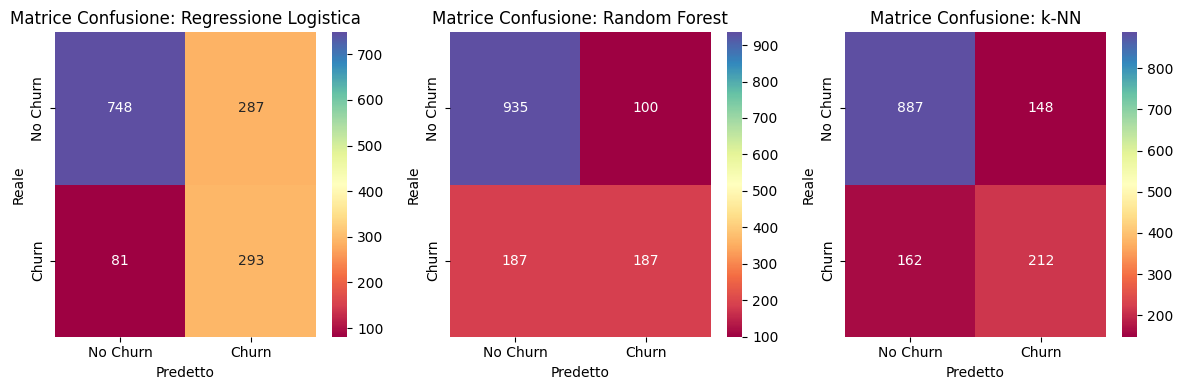


              Modello  Accuracy  Precision  Recall  F1-Score
Regressione Logistica    0.7388     0.5052  0.7834    0.6143
        Random Forest    0.7963     0.6516  0.5000    0.5658
                 k-NN    0.7800     0.5889  0.5668    0.5777


In [ ]:
results = []
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for idx, (name, model) in enumerate(models.items()):
    #creazione della Pipeline completa
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    #addestramento
    pipeline.fit(X_train, y_train)

    #predizione
    y_pred = pipeline.predict(X_test)

    #calcolo metriche per la classe positiva (Churn=1)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Modello": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4)
    })

    #applichiamo la soglia sulle probabilità
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    y_pred_custom = (y_prob >= 0.35).astype(int)


    #matrice di confusione
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Spectral', ax=axes[idx],
                xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
    axes[idx].set_title(f"Matrice Confusione: {name}")
    axes[idx].set_xlabel("Predetto")
    axes[idx].set_ylabel("Reale")

plt.tight_layout()
plt.show()

#tabella riassuntiva dei risultati
df_risultati = pd.DataFrame(results)
print()
print(df_risultati.to_string(index=False))

In presenza di dati sbilanciati, l'Accuracy da sola risulta fuorviante: un modello banale che predicesse sempre *No* otterrebbe oltre il 73% di accuratezza fallendo totalmente l'obiettivo. **Dal punto di vista del business, la Recall è la metrica più critica**, poiché minimizza i falsi negativi (i clienti che vogliono abbandonare ma che il modello non rileva).

A prima vista, il Random Forest mostra un'Accuracy vicina all'80% (79.63%).Andando però a guardare **la Recall per la classe Churn (*Yes*), il Random Forest si ferma ad appena il 50.00% e il k-NN al 56.68%**.

# Parte 4 - Valutazione e interpretazione dei risultati

## Domanda 4.1: quali ottimizzazioni possiamo attuare per migliorare la Recall?

Abbiamo osservato come i modelli iniziali **Random Forest** e **k-NN** mostrino **una Recall limitata (50% - 57%)**, lasciando inosservata circa la metà dei clienti in fase di abbandono.

In un problema sbilanciato come il Churn, **l'Accuracy da sola è una metrica ingannevole**. Se predicessimo sempre *No Churn*, avremmo il 73.5% di Accuracy senza aver individuato un solo cliente in uscita. Nell'ottica della compagnia, un falso negativo (un cliente che sta per abbandonare e che il modello non rileva) ha un costo immensamente superiore a un falso positivo (offrire uno sconto di fidelizzazione a chi non voleva andarsene). Per questo la metrica guida principale su cui ci siamo focalizzati è la Recall.

**Per superare le basse performance in termini di Recall e spingere i modelli a rilevare più casi di churn, integriamo le seguenti ottimizzazioni:**

#### 1. Modifica della soglia decisionale
Di default, gli algoritmi classificano un cliente come "Churn" solo se la probabilità calcolata supera il **50%** (0.50).
* **Intervento:** abbassiamo la soglia decisionale al **35%** (*CUSTOM_THRESHOLD = 0.35*). Rendendo il modello più "sensibile" ai segnali d'allarme, riusciamo a catturare un numero nettamente superiore di clienti a rischio che prima vengono classificati erroneamente come clienti stabili (*Falsi Negativi*).

#### 2. Bilanciamento delle classi con tecnica SMOTE
Il dataset è sbilanciato (73.5% *No Churn* vs 26.5% *Churn*). Algoritmi basati sulle distanze come il **k-NN** soffrono particolarmente questa sproporzione, tendendo a favorire la classe maggioritaria.
* **Intervento:** integriamo la tecnica **SMOTE** (*Synthetic Minority Over-sampling Technique*) all'interno della pipeline di addestramento. SMOTE genera esempi sintetici ma realistici della classe minoritaria (*Churn*), fornendo al modello un numero equilibrato di esempi da cui apprendere i pattern di abbandono. Modelli basati su distanze come il k-NN soffrono la presenza di classi maggioritarie. SMOTE genera esempi sintetici della classe minoritaria (*Churn*) nel set di addestramento.

#### 3. Ottimizzazione degli iperparametri focalizzata sulla Recall
I modelli tendono ad autottimizzarsi per l'Accuratezza generale, metrica poco indicativa in caso di classi sbilanciate.
* **Intervento:** utilizziamo *GridSearchCV* configurando espressamente il parametro *scoring='recall'*. In questo modo, il processo di ricerca degli iperparametri premia ed estrae le configurazioni di modello che garantiscono il massimo tasso di rilevamento del churn.

#### 4. Tuning specifici per gli algoritmi
* **Random Forest:** Vengono sintonizzati parametri come *max_depth* e *min_samples_leaf* per evitare l'overfitting sulla classe maggioritaria e migliorare la generalizzazione sui casi di abbandono.
* **k-NN:** Viene testato il parametro *weights='distance'*, assegnando un peso maggiore ai vicini più prossimi nell'opportunità di voto, evitando che la presenza numerica della classe maggioritaria schiacci i casi di churn nelle regioni di confine dello spazio vettoriale.

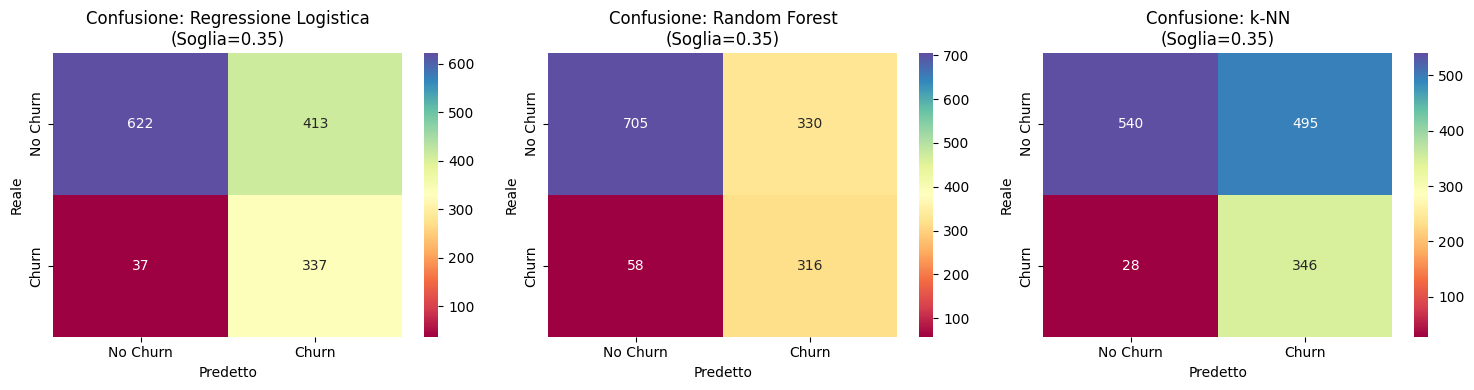


              Modello  Accuracy  Precision  Recall  F1-Score
Regressione Logistica    0.6806     0.4493  0.9011    0.5996
        Random Forest    0.7246     0.4892  0.8449    0.6196
                 k-NN    0.6288     0.4114  0.9251    0.5695


In [ ]:
param_grid_rf = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_leaf': [1, 2, 4]
}

param_grid_knn = {
    'classifier__n_neighbors': [5, 9, 15, 21],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean', 'manhattan']
}

param_grid_logreg = {
    'classifier__C': [0.1, 1.0, 10.0]
}

#configurazione dei modelli da confrontare
model_configs = {
    "Regressione Logistica": (
        LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"),
        param_grid_logreg
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=42, class_weight="balanced"),
        param_grid_rf
    ),
    "k-NN": (
        KNeighborsClassifier(),
        param_grid_knn
    )
}

#impostazione della soglia personalizzata per aumentare la recall
CUSTOM_THRESHOLD = 0.35

results = []
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

#ciclo di addestramento, tuning e valutazione
for idx, (name, (model, p_grid)) in enumerate(model_configs.items()):

    #creazione della pipeline con SMOTE per gestire lo sbilanciamento
    pipeline = ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("classifier", model)
    ])

    #ricerca iperparametri migliori ottimizzando per la recall
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=p_grid,
        scoring='recall',
        cv=5,
        n_jobs=-1
    )

    #addestramento
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_

    #estrazione probabilità della classe positiva (Churn=1)
    y_prob = best_model.predict_proba(X_test)[:, 1]

    #applicazione della soglia personalizzata
    y_pred_custom = (y_prob >= CUSTOM_THRESHOLD).astype(int)

    #calcolo metriche basato sulla soglia personalizzata
    acc = accuracy_score(y_test, y_pred_custom)
    prec = precision_score(y_test, y_pred_custom)
    rec = recall_score(y_test, y_pred_custom)
    f1 = f1_score(y_test, y_pred_custom)

    results.append({
        "Modello": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "Migliori Parametri": grid_search.best_params_
    })

    #matrice di confusione basata sulla soglia personalizzata
    cm = confusion_matrix(y_test, y_pred_custom)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Spectral', ax=axes[idx],
                xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
    axes[idx].set_title(f"Confusione: {name}\n(Soglia={CUSTOM_THRESHOLD})")
    axes[idx].set_xlabel("Predetto")
    axes[idx].set_ylabel("Reale")

plt.tight_layout()
plt.show()

print()

#tabella riassuntiva
df_risultati = pd.DataFrame(results)
print(df_risultati.drop(columns=["Migliori Parametri"]).to_string(index=False))

**NOTA:** se avessimo applicato SMOTE prima dello split, copie o combinazioni sintetiche di dati del test set sarebbero finite nel training set, sfalsando e sovrastimando le metriche di valutazione finale. È stato inserito nella ImbPipeline (di imblearn) affinché l'oversampling venisse applicato solo sui fold di addestramento e mai sul test set.

## Domanda 4.2: spiegabilità dei modelli e confronto

Confrontiamo le prestazioni ottimali ottenute dopo la cura dei dati (soglia 0.35 + SMOTE + tuning).

**k-NN (Recall 92.51%) e la Regressione Logistica (Recall 90.11%) intercettano quasi tutti i clienti**.

Tuttavia, **generano un numero elevato di falsi positivi**, rischiando di spendere troppo budget in campagne promozionali inutili

**Il Random Forest ottimizzato offre il miglior equilibrio di business**, poiché:

* porta la Recall dal 50% iniziale all'84.49% (quindi intercetta oltre 8 clienti a rischio su 10).

* mantiene la Precision (48.92%) e l'F1-Score (0.62) più alti tra tutti i modelli, riducendo le uscite di budget a vuoto rispetto agli altri due modelli.

* offre spiegabilità (Feature Importance) e permette all'azienda di capire perché i clienti abbandonano (es. tipo di contratto, tenure, costi mensili).

**Nel Random Forest, notiamo che l'Accuracy scende dal 79.6% al 72.5%: è una scelta consapevole di trade-off**.

Nel primo caso il modello era sbilanciato a favore dei 'No Churn', ottenendo un'alta Accuracy complessiva ma fallendo la Recall (50%). Nello scenario finale abbiamo dato priorità alla Recall.
Accettando qualche falso positivo in più (che abbassa leggermente l'Accuracy), siamo riusciti ad **aumentare la capacità di rilevare i reali casi di Churn dall'50% all'84.5%.**

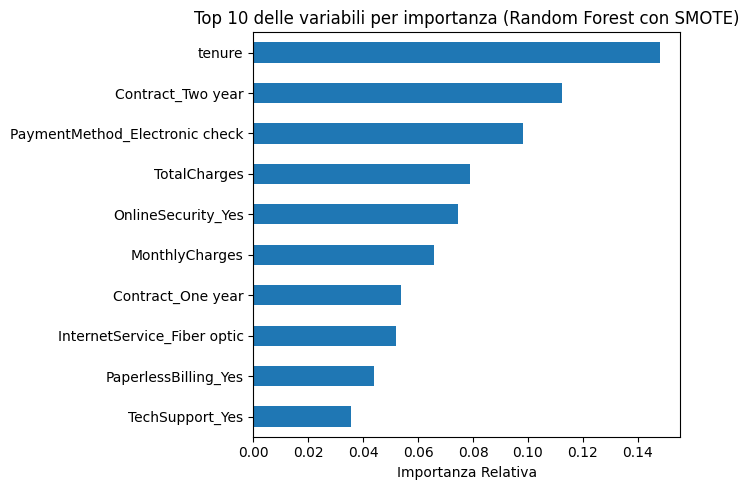

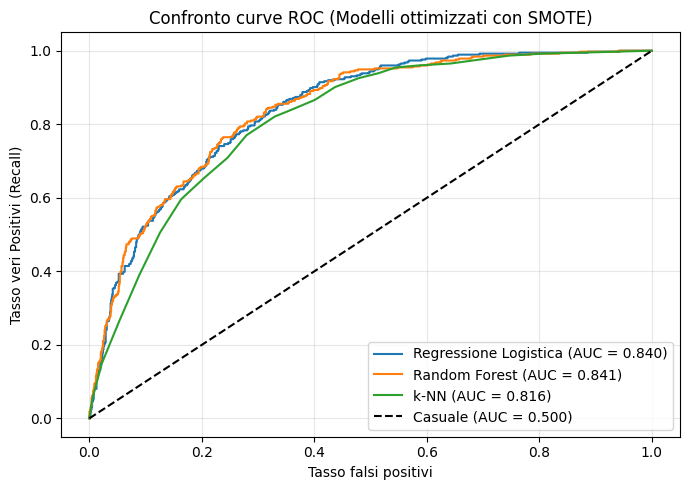

In [ ]:
#TOP 10 FEATURE IMPORTANCE (RANDOM FOREST)
# Estrazione dei nomi di tutte le feature (numeriche + categoriche One-Hot)
cat_encoder = preprocessor.named_transformers_['cat']
cat_names = cat_encoder.get_feature_names_out(cat_cols).tolist()
all_features = num_cols + cat_names

# Riaddestriamo la pipeline ottimizzata del Random Forest per estrarre le importanze
rf_best_params = [r['Migliori Parametri'] for r in results if r["Modello"] == "Random Forest"][0]

rf_pipe = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", RandomForestClassifier(random_state=42, class_weight="balanced"))
])
rf_pipe.set_params(**rf_best_params)
rf_pipe.fit(X_train, y_train)

# Estrazione delle importanze dal classificatore
importances = pd.Series(
    rf_pipe.named_steps['classifier'].feature_importances_,
    index=all_features
)

# Grafico delle prime 10 variabili
plt.figure(figsize=(7, 5))
importances.nlargest(10).plot.barh().invert_yaxis()
plt.title("Top 10 delle variabili per importanza (Random Forest con SMOTE)")
plt.xlabel("Importanza Relativa")
plt.tight_layout()
plt.show()


#CONFRONTO CURVE ROC
plt.figure(figsize=(7, 5))

for name, (model, p_grid) in model_configs.items():
    # Creazione pipeline con i migliori iperparametri trovati
    pipe = ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("classifier", model)
    ])

    best_params = [r["Migliori Parametri"] for r in results if r["Modello"] == name][0]
    pipe.set_params(**best_params)
    pipe.fit(X_train, y_train)

    # Calcolo probabilità e curva ROC
    y_prob = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], "k--", label="Casuale (AUC = 0.500)")
plt.title("Confronto curve ROC (Modelli ottimizzati con SMOTE)")
plt.xlabel("Tasso falsi positivi")
plt.ylabel("Tasso veri Positivi (Recall)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

La *Top 10* delle variabili ci permette di superare la natura a "scatola nera" del Random Forest. Dimostra che **l'abbandono non è causato da fattori demografici come il genere, ma da dinamiche di servizio ed economiche**: basso tenure, contratti mensili e assenza di servizi di assistenza. Questo dà alla compagnia indicazioni chiare su quali leve commerciali agire.

**L'azienda dovrebbe fidelizzare i clienti nei primi mesi e spingere su contratti pluriennali e pacchetti di supporto.**

La Curva ROC (*Receiver Operating Characteristic*) e il relativo valore AUC (*Area Under the Curve*) completano la valutazione, mostrando le prestazioni dei modelli indipendentemente da una singola soglia fissa.

La curva ROC e l'AUC dimostrano che il Random Forest e la Regressione Logistica mantengono una capacità discriminativa eccellente su qualsiasi soglia. **L'analisi della curva ROC ci ha fornito la prova teorica che abbassare la soglia decisionale a 0.35 era la scelta ottimale**: ci ha permesso di scalare la curva verso l'alto, massimizzando la Recall senza far esplodere i falsi positivi, per **intercettare oltre l'84% degli abbandoni**.